In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Phần 1 : xử lỷ dữ liệu

In [3]:
# ==============================
# 1. ĐỌC DỮ LIỆU
# ==============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


# đọc file csv
df = pd.read_csv("/content/drive/MyDrive/doan/motorbike_buyers.csv")


# xem kích thước dữ liệu
print("Kích thước dữ liệu:", df.shape)


# xem 5 dòng đầu
df.head()

Kích thước dữ liệu: (1000, 13)


,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Motorbike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes


In [4]:
# Kiểm tra thông tin

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   1000 non-null   int64  
 1   Marital Status       993 non-null    object 
 2   Gender               989 non-null    object 
 3   Income               994 non-null    float64
 4   Children             992 non-null    float64
 5   Education            1000 non-null   object 
 6   Occupation           1000 non-null   object 
 7   Home Owner           996 non-null    object 
 8   Cars                 991 non-null    float64
 9   Commute Distance     1000 non-null   object 
 10  Region               1000 non-null   object 
 11  Age                  992 non-null    float64
 12  Purchased Motorbike  1000 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 101.7+ KB


In [5]:
df.isnull().sum()

,0
ID,0
Marital Status,7
Gender,11
Income,6
Children,8
Education,0
Occupation,0
Home Owner,4
Cars,9
Commute Distance,0


In [6]:
# Kiểm tra dữ liệu trùng

print("Số dòng trùng:", df.duplicated().sum())

Số dòng trùng: 0


Phần 2 : EDA (Dữ liệu phân tích)

In [7]:
df.describe()

,ID,Income,Children,Cars,Age
count,1000.000000,994.000000,992.000000,991.000000,992.000000
mean,19965.992000,56267.605634,1.910282,1.455096,44.181452
std,5347.333948,31067.817462,1.626910,1.121755,11.362007
min,11000.000000,10000.000000,0.000000,0.000000,25.000000
25%,15290.750000,30000.000000,0.000000,1.000000,35.000000
50%,19744.000000,60000.000000,2.000000,1.000000,43.000000
75%,24470.750000,70000.000000,3.000000,2.000000,52.000000
max,29447.000000,170000.000000,5.000000,4.000000,89.000000


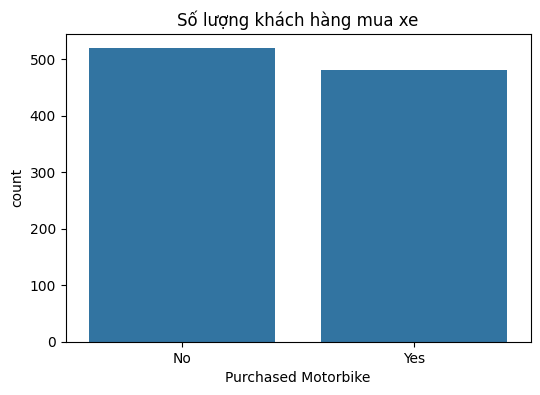

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Purchased Motorbike",
    data=df
)

plt.title("Số lượng khách hàng mua xe")

plt.show()

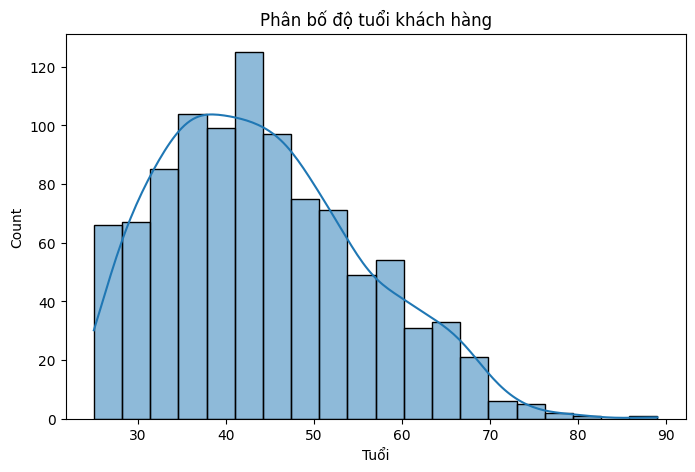

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)

plt.title("Phân bố độ tuổi khách hàng")

plt.xlabel("Tuổi")

plt.show()

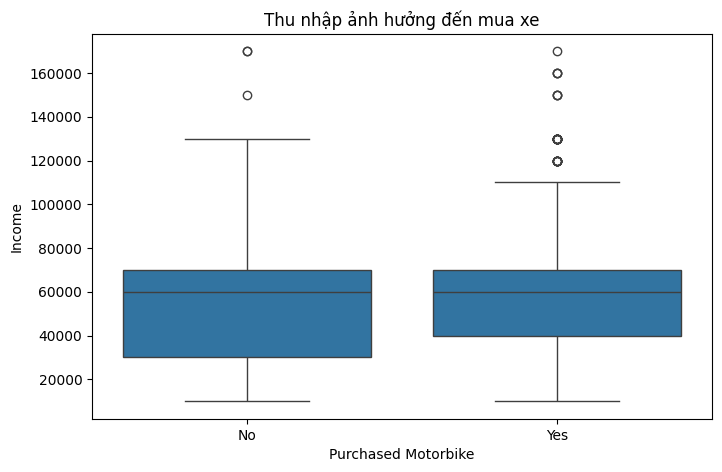

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Purchased Motorbike",
    y="Income",
    data=df
)

plt.title("Thu nhập ảnh hưởng đến mua xe")

plt.show()

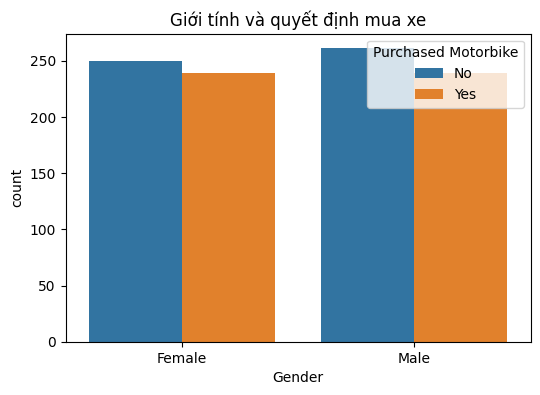

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Gender",
    hue="Purchased Motorbike",
    data=df
)

plt.title("Giới tính và quyết định mua xe")

plt.show()

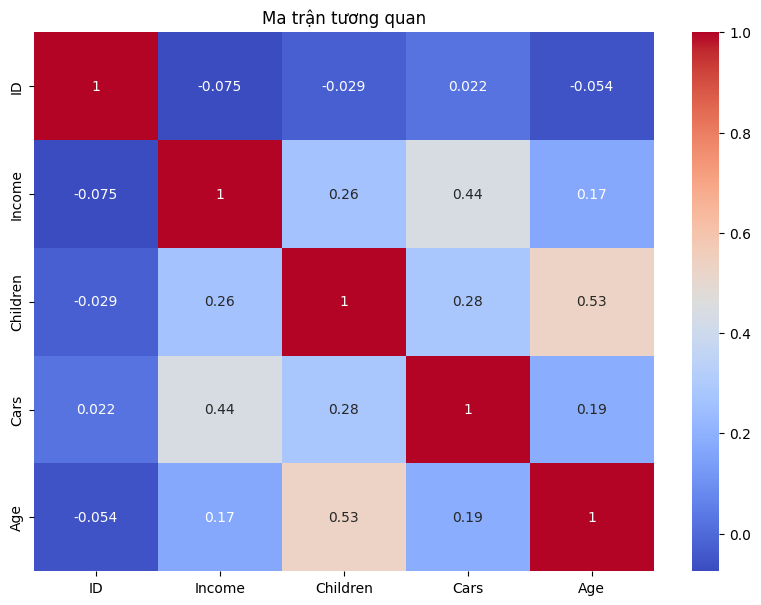

In [12]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Ma trận tương quan")

plt.show()

Phân 3 : Tiền xử lý dữ liệu

In [13]:
# Xử lý dữ liệu thiếu
for col in df.columns:

    if df[col].dtype == "object":

        df[col] = df[col].fillna(
            df[col].mode()[0]
        )

    else:

        df[col] = df[col].fillna(
            df[col].median()
        )

In [14]:
df.isnull().sum()

,0
ID,0
Marital Status,0
Gender,0
Income,0
Children,0
Education,0
Occupation,0
Home Owner,0
Cars,0
Commute Distance,0


In [15]:
# Chuyển đổi chữ số dữ liệu
df = pd.get_dummies(
    df,
    drop_first=True
)
print(df.columns.tolist())

['ID', 'Income', 'Children', 'Cars', 'Age', 'Marital Status_Single', 'Gender_Male', 'Education_Graduate Degree', 'Education_High School', 'Education_Partial College', 'Education_Partial High School', 'Occupation_Management', 'Occupation_Manual', 'Occupation_Professional', 'Occupation_Skilled Manual', 'Home Owner_Yes', 'Commute Distance_1-2 Miles', 'Commute Distance_10+ Miles', 'Commute Distance_2-5 Miles', 'Commute Distance_5-10 Miles', 'Region_North America', 'Region_Pacific', 'Purchased Motorbike_Yes']


In [16]:
# Tách dữ liệu
X = df.drop(
    "Purchased Motorbike_Yes",
    axis=1
)


y = df["Purchased Motorbike_Yes"]

In [17]:
# chia dữ liệu thành huấn luyện và để chọn mô hình học
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)


print(X_train.shape)

print(X_test.shape)

(800, 22)
(200, 22)


Phần 4 : HUẤN LUYỆN MÔ HÌNH

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

**1 LogisticRegression**

In [19]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

**2 DecisionTreeClassifier**



In [20]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(X_test)

**3 RandomForestClassifier**

In [36]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

**4 So sánh 3 mô hình**

In [31]:

result = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],

    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],

    "F1-score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]

})


result

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.575,0.549451,0.531915,0.540541
1,Decision Tree,0.655,0.640449,0.606383,0.622951
2,Random Forest,0.740,0.733333,0.702128,0.717391


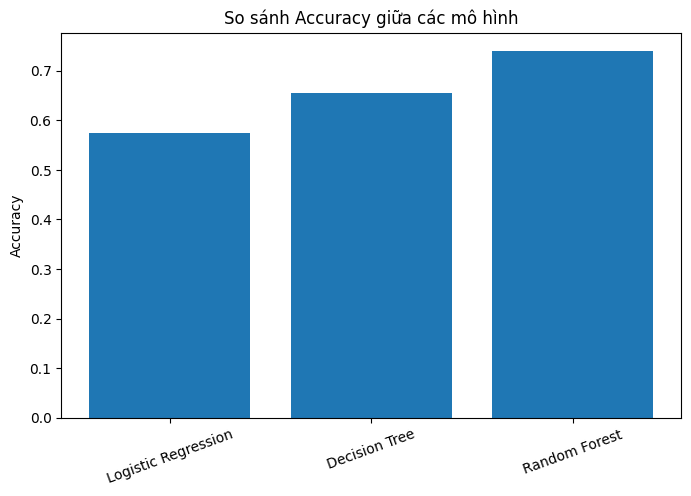

In [23]:
plt.figure(figsize=(8,5))

plt.bar(
    result["Model"],
    result["Accuracy"]
)

plt.title("So sánh Accuracy giữa các mô hình")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

model tốt nhất


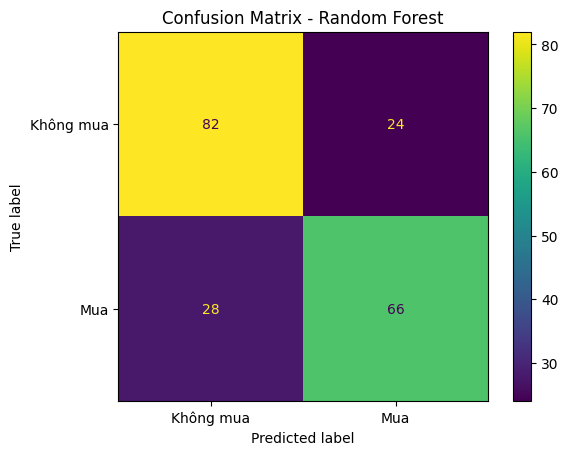

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Không mua", "Mua"]
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

Feature Importance

In [33]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,ID,0.193060
4,Age,0.171103
1,Income,0.101245
2,Children,0.086136
3,Cars,0.085552
5,Marital Status_Single,0.038748
6,Gender_Male,0.034784
15,Home Owner_Yes,0.028426
19,Commute Distance_5-10 Miles,0.025474
16,Commute Distance_1-2 Miles,0.023854


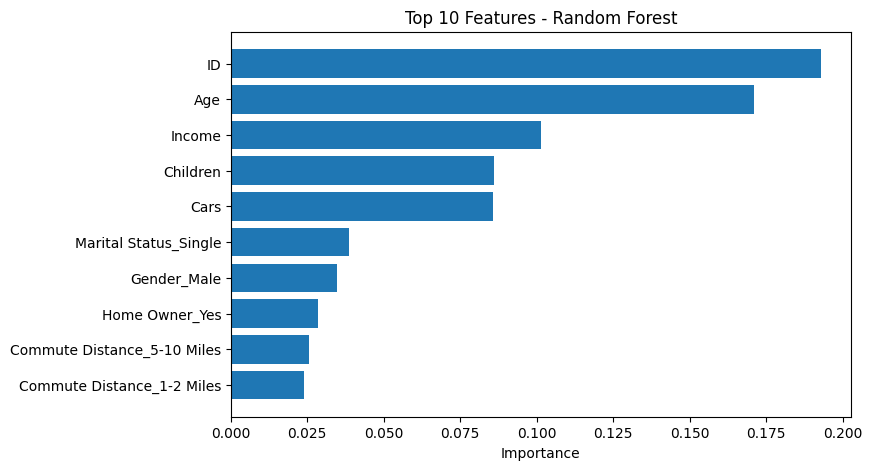

In [34]:
plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"].head(10)[::-1],
    feature_importance["Importance"].head(10)[::-1]
)

plt.xlabel("Importance")
plt.title("Top 10 Features - Random Forest")
plt.show()

**5 DỰ ĐOÁN**

In [24]:
customer = X_test[0:1]

customer

array([[-0.18494889, -0.50172623,  1.33520862,  0.51649542,  1.58706135,
         1.07263117,  0.97043679, -0.46255869,  2.19986728, -0.60430763,
        -0.29488391, -0.44654261, -0.37580157,  1.64429429, -0.57735027,
         0.67223926, -0.46852129,  3.        , -0.42828957, -0.48628803,
         0.99501244, -0.49217479]])

In [25]:
# Dự đoán

prediction = rf.predict(customer)


if prediction[0] == 1:
    print("Khách hàng có khả năng mua xe máy")
else:
    print("Khách hàng không có khả năng mua xe máy")

Khách hàng không có khả năng mua xe máy


In [26]:
# Xác suất dự đoán

probability = rf.predict_proba(customer)


print(
    "Khả năng không mua xe:",
    round(probability[0][0]*100,2),
    "%"
)


print(
    "Khả năng mua xe:",
    round(probability[0][1]*100,2),
    "%"
)

Khả năng không mua xe: 50.0 %
Khả năng mua xe: 50.0 %
